In [1]:
!pip install wordCloud

In [5]:
import pandas as pd

In [7]:
df = pd.read_csv("mabel.txt", header=None, encoding='utf8', on_bad_lines='skip')

In [8]:
dataset=df

In [9]:
df

,0,1
0,05/12/19,1:42 pm - Messages to this chat and calls are...
1,05/12/19,1:42 pm - Mabel Infoziant: Hi this is Mabel w...
2,05/12/19,1:42 pm - Mabel Infoziant: What’s your full name
3,05/12/19,1:42 pm - AR❤: Ramisha Rani K
4,05/12/19,1:42 pm - Mabel Infoziant: Ok
5,05/12/19,1:42 pm - Mabel Infoziant: ramisharanik@gmail...
6,05/12/19,1:43 pm - Mabel Infoziant: Your email Id?
7,05/12/19,1:43 pm - AR❤: Yes Mam
8,05/12/19,1:43 pm - Mabel Infoziant: I will send 2 abst...
9,05/12/19,1:43 pm - AR❤: Yeah mam


In [14]:
dataset.columns = ['Date', 'chat']

In [17]:
dataset[['Time', 'Rest']] = dataset['chat'].str.split(' - ', n=1, expand=True)

In [15]:
dataset

,Date,chat
0,05/12/19,1:42 pm - Messages to this chat and calls are...
1,05/12/19,1:42 pm - Mabel Infoziant: Hi this is Mabel w...
2,05/12/19,1:42 pm - Mabel Infoziant: What’s your full name
3,05/12/19,1:42 pm - AR❤: Ramisha Rani K
4,05/12/19,1:42 pm - Mabel Infoziant: Ok
5,05/12/19,1:42 pm - Mabel Infoziant: ramisharanik@gmail...
6,05/12/19,1:43 pm - Mabel Infoziant: Your email Id?
7,05/12/19,1:43 pm - AR❤: Yes Mam
8,05/12/19,1:43 pm - Mabel Infoziant: I will send 2 abst...
9,05/12/19,1:43 pm - AR❤: Yeah mam


In [19]:
df[['Time', 'Rest']] = df['chat'].str.split(' - ', n=1, expand=True)

In [22]:
df

,Date,chat,Time,Rest
0,05/12/19,1:42 pm - Messages to this chat and calls are...,1:42 pm,Messages to this chat and calls are now secure...
1,05/12/19,1:42 pm - Mabel Infoziant: Hi this is Mabel w...,1:42 pm,Mabel Infoziant: Hi this is Mabel we just spoke
2,05/12/19,1:42 pm - Mabel Infoziant: What’s your full name,1:42 pm,Mabel Infoziant: What’s your full name
3,05/12/19,1:42 pm - AR❤: Ramisha Rani K,1:42 pm,AR❤: Ramisha Rani K
4,05/12/19,1:42 pm - Mabel Infoziant: Ok,1:42 pm,Mabel Infoziant: Ok
5,05/12/19,1:42 pm - Mabel Infoziant: ramisharanik@gmail...,1:42 pm,Mabel Infoziant: ramisharanik@gmail.com
6,05/12/19,1:43 pm - Mabel Infoziant: Your email Id?,1:43 pm,Mabel Infoziant: Your email Id?
7,05/12/19,1:43 pm - AR❤: Yes Mam,1:43 pm,AR❤: Yes Mam
8,05/12/19,1:43 pm - Mabel Infoziant: I will send 2 abst...,1:43 pm,Mabel Infoziant: I will send 2 abstracts for u...
9,05/12/19,1:43 pm - AR❤: Yeah mam,1:43 pm,AR❤: Yeah mam


In [20]:
from wordcloud import WordCloud
from nltk.corpus import stopwords
import nltk
import matplotlib.pyplot as plt
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gnana\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

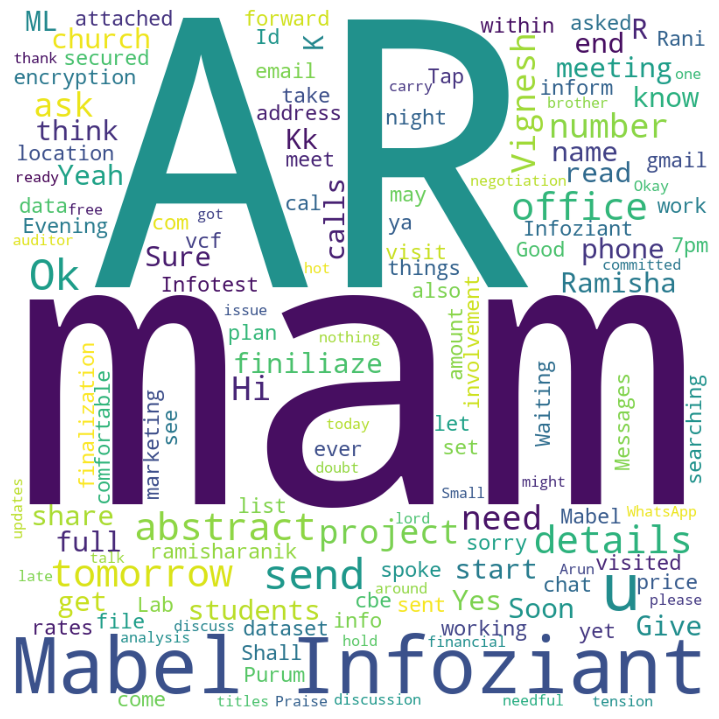

Successfully created


In [23]:
comment_words = []

stoplist = stopwords.words('english')
stoplist.extend(['omitted','voice','missed','call','video','deleted','media','message'])

dataset.index = range(dataset.shape[0])

# Collect all text
for i in range(len(dataset)):
    comment_words.append(str(dataset['Rest'][i]))

# Join once (OUTSIDE loop)
vv = " ".join(comment_words)

# Create wordcloud
wordcloud = WordCloud(
    width=800,
    height=800,
    background_color='white',
    stopwords=stoplist,
    min_font_size=10
).generate(vv)

# Plot
plt.figure(figsize=(9,7))
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)

plt.savefig('wordcloud.PNG')
plt.show()

print("Successfully created")